In [44]:
import pandas as pd
import numpy as np
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt

In [115]:
# LOADING THE DATAS

results     = pd.read_csv("/content/data/results.csv")
former_names = pd.read_csv("/content/data/former_names.csv")
goalscorers = pd.read_csv("/content/data/goalscorers.csv")
shootouts   = pd.read_csv("/content/data/shootouts.csv")


In [116]:
# INSPECTING THE DATA
print(f"results.csv       → {len(results):,} rows")
print(f"former_names.csv  → {len(former_names):,} rows")
print(f"goalscorers.csv   → {len(goalscorers):,} rows")
print(f"shootouts.csv     → {len(shootouts):,} rows")

results.csv       → 49,287 rows
former_names.csv  → 36 rows
goalscorers.csv   → 47,601 rows
shootouts.csv     → 675 rows


# DATA CLEANING

## WORKING ON RESULTS.CSV

In [117]:
# INSPECTING RESULTS
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [118]:
results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49286,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,True


In [119]:
# INSPECTING NULL VALUES
results.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,72
away_score,72
tournament,0
city,0
country,0
neutral,0


In [120]:
# PARSING THE DATES PROPERLY
results["date"] = pd.to_datetime(results["date"])

In [121]:
# SPLITING UP THE DATA INTO COMPLETED MATCHES VS FUTURE SCHEDULED FIXTURES
future_matches = results[results["home_score"].isnull()].copy()
results = results[results["home_score"].notna()].copy()

In [122]:
# INSPECTING FUTURE MATCHS
future_matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49215,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49216,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49217,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49218,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49219,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True


In [123]:
# INSPECTING PAST MATCHES
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [124]:
# ENSURING THE SCORE COLUMNS OF ALREADY PLAYED MATCHES TO INTEGERS
results["home_score"] = results["home_score"].astype(int)
results["away_score"] = results["away_score"].astype(int)

In [125]:
# REMOVING EXTRA WHITE SPACES FROM THE STRING COLUMNS
for col in ["home_team", "away_team", "tournament", "city", "country"]:
  results[col] = results[col].str.strip()

In [126]:
print("Number of completed matches: ", len(results))
print("Number of future matches in 2026: ", len(future_matches))

Number of completed matches:  49215
Number of future matches in 2026:  72


## WORKING ON GOALSCORERS.CSV

In [127]:
# INSPECTING GOAL SCORERS DATASET
goalscorers.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [128]:
# INSPECTING GOAL SCORERS DATASET
goalscorers.tail()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
47596,2026-03-31,Sweden,Poland,Sweden,Anthony Elanga,20.0,False,False
47597,2026-03-31,Sweden,Poland,Poland,Nicola Zalewski,33.0,False,False
47598,2026-03-31,Sweden,Poland,Sweden,Gustaf Lagerbielke,44.0,False,False
47599,2026-03-31,Sweden,Poland,Poland,Karol Świderski,55.0,False,False
47600,2026-03-31,Sweden,Poland,Sweden,Viktor Gyökeres,88.0,False,False


In [129]:
# INSPECTING NULL VALUES
goalscorers.isnull().sum()

,0
date,0
home_team,0
away_team,0
team,0
scorer,48
minute,256
own_goal,0
penalty,0


In [130]:
# PARSING THE DATES PROPERLY
goalscorers["date"] = pd.to_datetime(goalscorers["date"])

In [131]:
# FILLING THE MISSING VALUES AS 'UNKNOWN'
goalscorers["scorer"] = goalscorers["scorer"].fillna("Unknown")

In [132]:
# FILLING MISSING TIME OF GOAL SCORED AS -1
goalscorers["minute"] = goalscorers["minute"].fillna(-1).astype(int)

In [133]:
# REMOVING EXTRA WHITE SPACES FROM THE STRING COLUMNS
for col in ["home_team", "away_team", "team", "scorer"]:
  goalscorers[col] = goalscorers[col].str.strip()

In [134]:
goalscorers.isnull().sum()

,0
date,0
home_team,0
away_team,0
team,0
scorer,0
minute,0
own_goal,0
penalty,0


## SHOOTOUTS.CSV

In [135]:
# INSPECTING SHOOTOUT DATASET
shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [136]:
# INSPECTING SHOOTOUT DATASET
shootouts.tail()

,date,home_team,away_team,winner,first_shooter
670,2026-03-30,Cape Verde,Finland,Cape Verde,Cape Verde
671,2026-03-30,Gabon,Trinidad and Tobago,Gabon,NaN
672,2026-03-30,Uzbekistan,Venezuela,Uzbekistan,NaN
673,2026-03-31,Bosnia and Herzegovina,Italy,Bosnia and Herzegovina,Bosnia and Herzegovina
674,2026-03-31,Czech Republic,Denmark,Czech Republic,Denmark


In [137]:
# INSPECTING NULL VALUES
shootouts.isnull().sum()

,0
date,0
home_team,0
away_team,0
winner,0
first_shooter,429


We can see there are 429 NaN values for first_shooter in the dataset, lets analyze it further

In [138]:
# FORMATING DATE
shootouts["date"] = pd.to_datetime(shootouts["date"])

In [139]:
# Extract year
shootouts["year"] = shootouts["date"].dt.year

In [140]:
# ADDING COLUMN FOR MISSING SHOOTER
shootouts["missing_first_shooter"] = shootouts["first_shooter"].isna()


In [141]:

# AGGREGATING BY YEAR
yearly_missing = (
    shootouts.groupby("year")
    .agg(
        total_shootouts=("first_shooter", "size"),
        missing_count=("missing_first_shooter", "sum")
    )
    .reset_index()
)

In [142]:
# CALCULATING MISSING PERCENTAGE
yearly_missing["missing_pct"] = (
    yearly_missing["missing_count"] /
    yearly_missing["total_shootouts"]
) * 100

print(yearly_missing.head(20))

    year  total_shootouts  missing_count  missing_pct
0   1967                1              1   100.000000
1   1971                1              1   100.000000
2   1972                3              3   100.000000
3   1973               11             11   100.000000
4   1974                6              6   100.000000
5   1975                4              4   100.000000
6   1976                2              1    50.000000
7   1977                5              5   100.000000
8   1979                6              5    83.333333
9   1980                6              5    83.333333
10  1981                3              3   100.000000
11  1982                8              7    87.500000
12  1983               10             10   100.000000
13  1984               16             15    93.750000
14  1985               11             11   100.000000
15  1986               11              8    72.727273
16  1987               11             11   100.000000
17  1988               14   

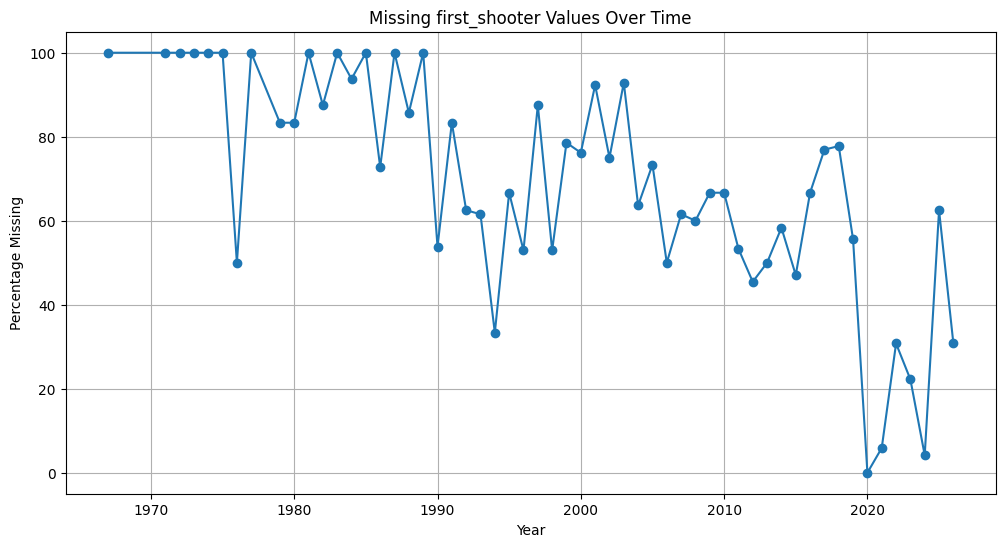

In [143]:
# VISUALIZING MISSING SHOOTER PER YEAR
plt.figure(figsize=(12,6))

plt.plot(
    yearly_missing["year"],
    yearly_missing["missing_pct"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Percentage Missing")
plt.title("Missing first_shooter Values Over Time")

plt.grid(True)

plt.show()

We can see that most of the missing shooter are from the beginning era. So its possible that they did not record the data at all. Hence it would be better to leave missing shooter as a historical gap.

In [144]:
# REMOVING WHITE SPACES FROM STRING COLUMNS
for col in ["home_team", "away_team", "winner"]:
  shootouts[col] = shootouts[col].str.strip()

## FORMER NAME DATASET

In [145]:
# INSPECTING FORMER NAMES DATASET
former_names.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [146]:
former_names.tail()

,current,former,start_date,end_date
31,Suriname,Dutch Guyana,1921-01-28,1975-11-25
32,Tanzania,Tanganyika,1945-01-01,1964-04-26
33,Vanuatu,New Hebrides,1951-10-04,1980-07-30
34,Zambia,Northern Rhodesia,1947-02-22,1964-10-25
35,Zimbabwe,Southern Rhodesia,1946-06-16,1980-04-18


In [147]:
# FORMATING DATETIME
former_names["start_date"] = pd.to_datetime(former_names["start_date"])
former_names["end_date"]   = pd.to_datetime(former_names["end_date"])


## RESOLVING HISTORICAL TEAM NAME
- As some team had different name before and their name changed at a later point in history, we change their name in the dataset so that we can deal with the current names of the teams.

In [148]:
# BUILDING A FLAT LOOK UP
name_map = dict(zip(former_names["former"], former_names["current"]))

In [149]:
# FUNCTION TO RESOLVE NAMES
def resolve_name(name):
  return name_map.get(name, name)

In [150]:
# APPLYING NAME RESOLUTION TO GOAL_SCORER AND SHOOTOUT DATASET
for df_name, df in [("goalscorers", goalscorers), ("shootouts", shootouts)]:
  before_home = df["home_team"].unique()
  df["home_team"] = df["home_team"].apply(resolve_name)
  df["away_team"] = df["away_team"].apply(resolve_name)

  if "team" in df.columns:
    df["team"] = df["team"].apply(resolve_name)
  if "winner" in df.columns:
    df["winner"] = df["winner"].apply(resolve_name)


In [151]:
# ADDING A NEW COLUMN 'team_name_at_time' REPRESENTING NAME OF THE TEAM WHEN THEY PLAYED MATCH
# SPECIALLY USEFUL FOR TEAMS WHOSE NAME CHANGED OVER TIME
def get_name_at_time(team, date, former_names_df):
  mask = (
      (former_names_df["current"] == team) &
      (former_names_df["start_date"] <= date) &
      (former_names_df["end_date"] >= date)
  )
  match = former_names_df[mask]

  if not match.empty:
    return match.iloc[0]['former']
  return team

## FEATURE ENGINEERING

In [152]:
# INSPECTING MATCH RESULT FROM HOME TEAM PERSPECTIVE
def get_result(row):
  if row["home_score"] > row["away_score"]:
    return "home_win"
  elif row["home_score"] < row["away_score"]:
    return "away_win"
  else:
    return "draw"

In [153]:
results["result"] = results.apply(get_result, axis = 1)
print(f"result column: {results['result'].value_counts().to_dict()}")

result column: {'home_win': 24106, 'away_win': 13912, 'draw': 11197}


In [154]:
# INSPECTING GOAL DIFFERENCE
results["goal_diff"] = results["home_score"] - results["away_score"]
results["total_goals"] = results["home_score"] + results["away_score"]

In [155]:
results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_diff,total_goals
49210,2026-03-31,Kosovo,Turkey,0,1,FIFA World Cup qualification,Pristina,Kosovo,False,away_win,-1,1
49211,2026-03-31,Czech Republic,Denmark,2,2,FIFA World Cup qualification,Prague,Czech Republic,False,draw,0,4
49212,2026-03-31,Cameroon,China PR,2,0,FIFA Series,Melbourne,Australia,True,home_win,2,2
49213,2026-03-31,Australia,Curaçao,5,1,FIFA Series,Melbourne,Australia,False,home_win,4,6
49214,2026-03-31,Kazakhstan,Comoros,1,0,FIFA Series,Astana,Kazakhstan,False,home_win,1,1


In [156]:
# ADDING SOME TIME FEATURES
results["year"] = results["date"].dt.year
results["month"] = results["date"].dt.month
results["decade"] = (results["year"] // 10 ) * 10

In [157]:
# ERA CLASSIFICATION
def classify_era(year):
  if year < 1900:
    return "Pioneer Era (pre-1900)"
  elif year < 1930:
    return "Early Era (1900-1929)"
  elif year < 1950:
    return "Pre-WC Era (1930-1949)"
  elif year < 1970:
    return "Classic Era (1950-1969)"
  elif year < 1990:
    return "Modern Foundation (1970-1989)"
  elif year < 2010:
    return "Globalization Era (1990-2009)"
  else:
    return "Contemporary Era (2010+)"

results["era"] = results["year"].apply(classify_era)

In [158]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_diff,total_goals,year,month,decade,era
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,0,0,1872,11,1870,Pioneer Era (pre-1900)
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,2,6,1873,3,1870,Pioneer Era (pre-1900)
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,1,3,1874,3,1870,Pioneer Era (pre-1900)
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,0,4,1875,3,1870,Pioneer Era (pre-1900)
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,3,3,1876,3,1870,Pioneer Era (pre-1900)


## TOURNAMENT TIER
We are going to divide the games into following tiers:
1. Tier 1: Major Events (World Cup, Continental championships)
2. Tier 2: Qualifications for major tournaments
3. Tier 3: Regional tournaments and cups
4. Tier 4: Friendlies and minor tournaments

In [159]:

tier1_tournaments = {
    "FIFA World Cup", "Copa América", "African Cup of Nations",
    "UEFA Euro", "AFC Asian Cup", "CONCACAF Gold Cup",
    "OFC Nations Cup", "COSAFA Cup final", "Copa America"
}

tier2_keywords = ["qualification", "qualifying", "qualifier"]

tier3_keywords = [
    "Nations League", "Gold Cup", "CECAFA", "COSAFA", "WAFU",
    "Merdeka", "Gulf Cup", "Caribbean Cup", "EAFF", "SAFF",
    "King's Cup", "Kirin Cup", "Intercontinental"
]

In [160]:
def classify_tier(tournament):
  t = tournament.strip()
  t_lower = t.lower()
  if t in tier1_tournaments:
    return 1
  if any(k in t_lower for k in tier2_keywords):
    return 2
  if any(k in t_lower for k in tier3_keywords):
    return 3
  if t_lower == "Friendly".lower():
    return 4
  return 3 # OTHER REGIONAL TOURNAMENT AS DEFAULT

In [161]:
results["tournament_tier"] = results["tournament"].apply(classify_tier)
tier_counts = results["tournament_tier"].value_counts().sort_index()
print(f"Tournament Tier count: {tier_counts.to_dict()}")

Tournament Tier count: {1: 3487, 2: 15927, 3: 11549, 4: 18252}


In [162]:
# CREATING COLUMN FOR HIGH STAKE MATCH
results["is_high_stakes"] = results["tournament_tier"] <= 2

In [163]:
# COLUMN FOR HOME ADVANTAGE FLAG
results["has_home_advantage"] = ~results["neutral"]

In [164]:
results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_diff,total_goals,year,month,decade,era,tournament_tier,is_high_stakes,has_home_advantage
49210,2026-03-31,Kosovo,Turkey,0,1,FIFA World Cup qualification,Pristina,Kosovo,False,away_win,-1,1,2026,3,2020,Contemporary Era (2010+),2,True,True
49211,2026-03-31,Czech Republic,Denmark,2,2,FIFA World Cup qualification,Prague,Czech Republic,False,draw,0,4,2026,3,2020,Contemporary Era (2010+),2,True,True
49212,2026-03-31,Cameroon,China PR,2,0,FIFA Series,Melbourne,Australia,True,home_win,2,2,2026,3,2020,Contemporary Era (2010+),3,False,False
49213,2026-03-31,Australia,Curaçao,5,1,FIFA Series,Melbourne,Australia,False,home_win,4,6,2026,3,2020,Contemporary Era (2010+),3,False,True
49214,2026-03-31,Kazakhstan,Comoros,1,0,FIFA Series,Astana,Kazakhstan,False,home_win,1,1,2026,3,2020,Contemporary Era (2010+),3,False,True


## JOINING SHOOTOUT OUTCOMES

In [165]:
shootouts.head()

,date,home_team,away_team,winner,first_shooter,year,missing_first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN,1967,True
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN,1971,True
2,1972-05-07,South Korea,Iraq,Iraq,NaN,1972,True
3,1972-05-17,Thailand,South Korea,South Korea,NaN,1972,True
4,1972-05-19,Thailand,Cambodia,Thailand,NaN,1972,True


In [166]:
shootouts.tail()

,date,home_team,away_team,winner,first_shooter,year,missing_first_shooter
670,2026-03-30,Cape Verde,Finland,Cape Verde,Cape Verde,2026,False
671,2026-03-30,Gabon,Trinidad and Tobago,Gabon,NaN,2026,True
672,2026-03-30,Uzbekistan,Venezuela,Uzbekistan,NaN,2026,True
673,2026-03-31,Bosnia and Herzegovina,Italy,Bosnia and Herzegovina,Bosnia and Herzegovina,2026,False
674,2026-03-31,Czech Republic,Denmark,Czech Republic,Denmark,2026,False


In [167]:
shootouts_temp = shootouts[["date", "home_team", "away_team", "winner", "first_shooter"]].copy()
shootouts_temp = shootouts_temp.rename(columns={
    "winner": "shootout_winner",
    "first_shooter": "shootout_first_shooter"
})

In [168]:
results = results.merge(shootouts_temp, on=["date", "home_team", "away_team"], how="left")


In [169]:
results["went_to_shootout"] = results["shootout_winner"].notna()

In [170]:
print(f"Joined {results['went_to_shootout'].sum()} shootout records into results")


Joined 674 shootout records into results


In [173]:
results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,year,month,decade,era,tournament_tier,is_high_stakes,has_home_advantage,shootout_winner,shootout_first_shooter,went_to_shootout
49210,2026-03-31,Kosovo,Turkey,0,1,FIFA World Cup qualification,Pristina,Kosovo,False,away_win,...,2026,3,2020,Contemporary Era (2010+),2,True,True,NaN,NaN,False
49211,2026-03-31,Czech Republic,Denmark,2,2,FIFA World Cup qualification,Prague,Czech Republic,False,draw,...,2026,3,2020,Contemporary Era (2010+),2,True,True,Czech Republic,Denmark,True
49212,2026-03-31,Cameroon,China PR,2,0,FIFA Series,Melbourne,Australia,True,home_win,...,2026,3,2020,Contemporary Era (2010+),3,False,False,NaN,NaN,False
49213,2026-03-31,Australia,Curaçao,5,1,FIFA Series,Melbourne,Australia,False,home_win,...,2026,3,2020,Contemporary Era (2010+),3,False,True,NaN,NaN,False
49214,2026-03-31,Kazakhstan,Comoros,1,0,FIFA Series,Astana,Kazakhstan,False,home_win,...,2026,3,2020,Contemporary Era (2010+),3,False,True,NaN,NaN,False


## AGGREGATING GOALSCORRER STATS
From the goalscorers table, we create per-match summaries:
- goals_by_home_team, goals_by_away_team
- own_goals count
- penalties count
- top_scorer_in_match

In [176]:
match_goal_stats = goalscorers.groupby(["date", "home_team", "away_team"]).agg(
    total_goals_recorded = ("scorer", "count"),
    own_goals_count      = ("own_goal", "sum"),
    penalties_count      = ("penalty", "sum"),
    unique_scorers       = ("scorer", "nunique")
).reset_index()



In [179]:
results = results.merge(match_goal_stats, on=["date", "home_team", "away_team"], how="left")


In [185]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,tournament_tier,is_high_stakes,has_home_advantage,shootout_winner,shootout_first_shooter,went_to_shootout,total_goals_recorded,own_goals_count,penalties_count,unique_scorers
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,...,4,False,True,NaN,NaN,False,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,...,4,False,True,NaN,NaN,False,NaN,NaN,NaN,NaN
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,...,4,False,True,NaN,NaN,False,NaN,NaN,NaN,NaN
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,...,4,False,True,NaN,NaN,False,NaN,NaN,NaN,NaN
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,...,4,False,True,NaN,NaN,False,NaN,NaN,NaN,NaN


In [186]:
results.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,tournament_tier,is_high_stakes,has_home_advantage,shootout_winner,shootout_first_shooter,went_to_shootout,total_goals_recorded,own_goals_count,penalties_count,unique_scorers
49210,2026-03-31,Kosovo,Turkey,0,1,FIFA World Cup qualification,Pristina,Kosovo,False,away_win,...,2,True,True,NaN,NaN,False,1.0,0.0,0.0,1.0
49211,2026-03-31,Czech Republic,Denmark,2,2,FIFA World Cup qualification,Prague,Czech Republic,False,draw,...,2,True,True,Czech Republic,Denmark,True,4.0,0.0,0.0,4.0
49212,2026-03-31,Cameroon,China PR,2,0,FIFA Series,Melbourne,Australia,True,home_win,...,3,False,False,NaN,NaN,False,NaN,NaN,NaN,NaN
49213,2026-03-31,Australia,Curaçao,5,1,FIFA Series,Melbourne,Australia,False,home_win,...,3,False,True,NaN,NaN,False,NaN,NaN,NaN,NaN
49214,2026-03-31,Kazakhstan,Comoros,1,0,FIFA Series,Astana,Kazakhstan,False,home_win,...,3,False,True,NaN,NaN,False,NaN,NaN,NaN,NaN


Since there are NaN values in the new columns we impute them as follows

In [187]:
for col in ["total_goals_recorded",
            "own_goals_count", "penalties_count", "unique_scorers"]:
            results[col] = results[col].fillna(0).astype(int)


In [188]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,tournament_tier,is_high_stakes,has_home_advantage,shootout_winner,shootout_first_shooter,went_to_shootout,total_goals_recorded,own_goals_count,penalties_count,unique_scorers
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,...,4,False,True,NaN,NaN,False,0,0,0,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,...,4,False,True,NaN,NaN,False,0,0,0,0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,...,4,False,True,NaN,NaN,False,0,0,0,0
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,...,4,False,True,NaN,NaN,False,0,0,0,0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,...,4,False,True,NaN,NaN,False,0,0,0,0


In [190]:

print(f"Joined goalscorer aggregates for {match_goal_stats.shape[0]:,} matches")
print(f"{results['total_goals_recorded'].eq(0).sum():,} matches have no goalscorer records (historical gap)")


Joined goalscorer aggregates for 15,440 matches
33,775 matches have no goalscorer records (historical gap)


## EXPORTING PREPROCESSED DATA

## SAVE CLEAN_MATCHES.CSV

In [191]:
output_cols = [
    "date", "year", "month", "decade", "era",
    "home_team", "away_team",
    "home_score", "away_score", "goal_diff", "total_goals",
    "result", "went_to_shootout", "shootout_winner", "shootout_first_shooter",
    "tournament", "tournament_tier", "is_high_stakes",
    "city", "country", "neutral", "has_home_advantage",
    "total_goals_recorded", "own_goals_count", "penalties_count", "unique_scorers"
]

clean_matches = results[output_cols].copy()
clean_matches.to_csv("clean_matches.csv", index=False)
print(f"clean_matches.csv → {len(clean_matches):,} rows × {len(output_cols)} columns")


clean_matches.csv → 49,215 rows × 26 columns


## SAVE CLEAN_GOALSCORERS.CSV

In [192]:
goalscorers.to_csv("clean_goalscorers.csv", index=False)
print(f"clean_goalscorers.csv → {len(goalscorers):,} rows")

clean_goalscorers.csv → 47,601 rows


## SAVE FUTURE_MATCHES.CSV

In [194]:
future_matches.to_csv("future_matches.csv", index=False)
print(f"future_matches.csv → {len(future_matches):,} upcoming fixtures saved separately")

future_matches.csv → 72 upcoming fixtures saved separately


## SAVING TO SQLite

In [196]:
conn = sqlite3.connect("football_analytics.db")
clean_matches.to_sql("matches", conn, if_exists="replace", index=False)
goalscorers.to_sql("goalscorers", conn, if_exists="replace", index=False)
shootouts.to_sql("shootouts", conn, if_exists="replace", index=False)
former_names.to_sql("former_names", conn, if_exists="replace", index=False)
future_matches.to_sql("future_matches", conn, if_exists="replace", index=False)
conn.close()
print(f"football_analytics.db → 5 tables: matches, goalscorers, shootouts, former_names, future_matches")


football_analytics.db → 5 tables: matches, goalscorers, shootouts, former_names, future_matches
